<a href="https://colab.research.google.com/github/aparna-2001/basic_BCI_analysis/blob/main/BCI_S001R08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 31.3 MB/s eta 0:00:00


In [3]:
import mne
from mne.decoding import CSP
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix

Extracting EDF parameters from S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Using matplotlib as 2D backend.


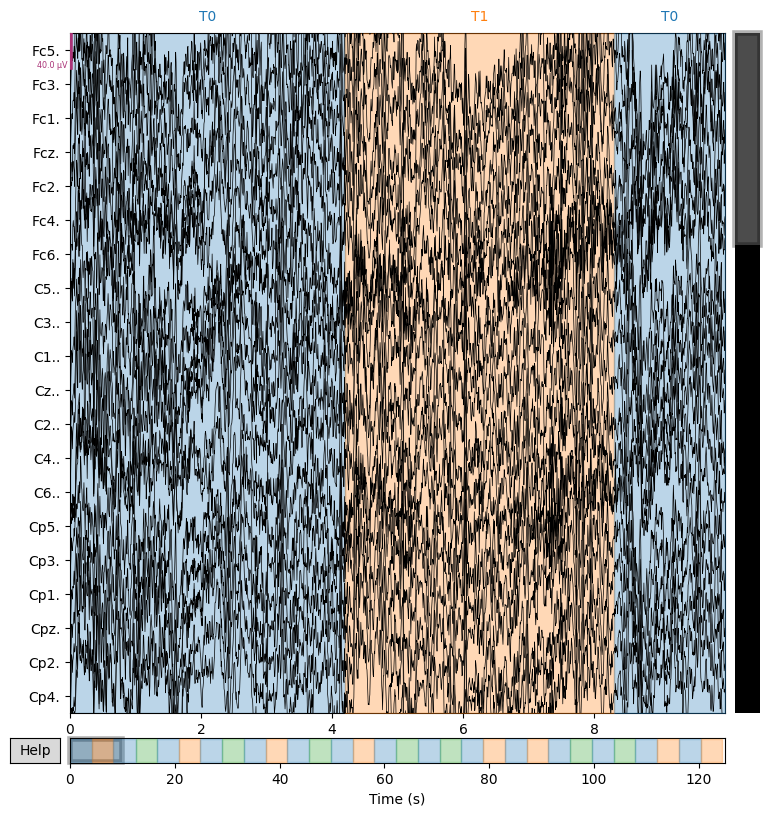

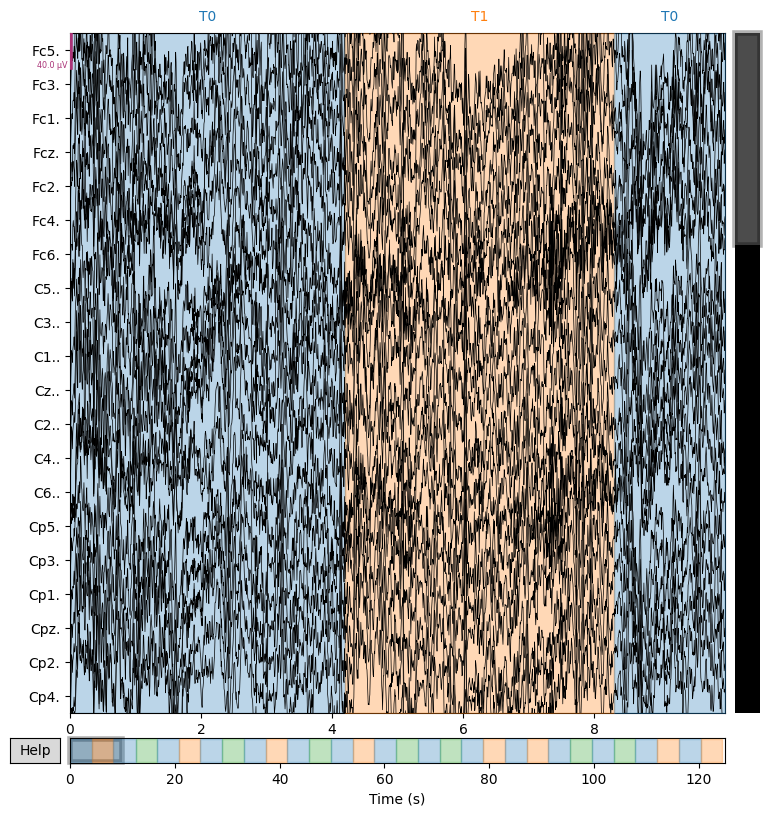

In [4]:
# loading the data

raw = mne.io.read_raw_edf('S001R08.edf', preload = True)
raw.plot()

In [5]:
#filtering the motor imagery data hertz

raw.filter(8,30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R08.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [6]:
events, event_id = mne.events_from_annotations(raw)

print(events)
print(event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[[    0     0     1]
 [  672     0     2]
 [ 1328     0     1]
 [ 2000     0     3]
 [ 2656     0     1]
 [ 3328     0     2]
 [ 3984     0     1]
 [ 4656     0     3]
 [ 5312     0     1]
 [ 5984     0     2]
 [ 6640     0     1]
 [ 7312     0     3]
 [ 7968     0     1]
 [ 8640     0     2]
 [ 9296     0     1]
 [ 9968     0     3]
 [10624     0     1]
 [11296     0     3]
 [11952     0     1]
 [12624     0     2]
 [13280     0     1]
 [13952     0     2]
 [14608     0     1]
 [15280     0     3]
 [15936     0     1]
 [16608     0     3]
 [17264     0     1]
 [17936     0     2]
 [18592     0     1]
 [19264     0     2]]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [7]:
epoch = mne.Epochs(raw = raw,
                    events = events,
                    event_id = event_id,
                    tmin = 0,
                    tmax = 4,
                    baseline = None,
                    preload = True)

epoch_T0 = epoch['T0']
epoch_T2 = epoch['T2']

time_T0 = epoch_T0.times
time_T2 = epoch_T2.times

#print(time_T0)
#print(time_T2)

#print(time_T0.min())
#print(time_T0.max())
#print(time_T2.min())
#print(time_T2.max())


Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
0 bad epochs dropped


In [8]:
#labels

labels_T2 = epoch_T2.events[:,-1]
print(labels_T2)

#labels_T0 = epoch_T0.events[:, -1]
#print(labels_T2)

[3 3 3 3 3 3 3]


In [9]:
#data

data_T0 = epoch_T0.get_data()
data_T2 = epoch_T2.get_data()

x = np.concatenate([data_T0, data_T2])
y = np.concatenate([np.zeros(len(epoch_T0)), np.ones(len(epoch_T2))])

print(x.shape)
print(y.shape)

(22, 64, 641)
(22,)


In [10]:
#csp

csp = CSP(n_components= 4, log = True)
x_csp = csp.fit_transform(x,y)

print(csp)
print(x_csp)

Computing rank from data with rank=None
    Using tolerance 0.00021 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.
CSP(log=True)
[[-0.78668606 -0.53953666 -1.17890424 -0.6276978 ]
 [-1.26154351 -1.12661082 -1.33254343 -0.78193751]
 [-1.18038877 -0.93753866 -1.26820423 -0.52227017]
 [-0.91376913 -0.93656896 -1.24698194 -0.32989119]
 [ 1.48810547  0.44655927 -1.07312832 -0.12836584]
 [-0.92497442 -0.90100083 -1.05029841 -0.67272194]
 [-0.78353631 -0.04781184 -0.90079692 -0.16878027]
 [-0.51763527  0.08707316 -1.13621358 -0.23841403]
 [-0.44888184 -0.61115145 -0.79291696 -0.54635336]
 [-0.68253104 -0.46646123 -0.89865598 -0.12503021]
 [-0.83377314 -0.24906173 -1.03597837 -0.32925298]
 [-0.68512096 -0.1292786  -1.06026248 -0.31503952]
 [-0.62526445 -

In [11]:
#LDA

clf = LinearDiscriminantAnalysis()
print(clf)

LinearDiscriminantAnalysis()


In [12]:
# dividing the data into training and test

x_train, x_test, y_train, y_test = train_test_split(x_csp, y, test_size= 0.3, random_state = 42)

#fitting
clf.fit(x_train, y_train)

#scoring
score = clf.score(x_test, y_test)

y_pred = clf.predict(x_test)
print(score)
print(y_pred)

1.0
[0. 0. 0. 0. 1. 0. 1.]


In [13]:
#validation using confusion matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5 0]
 [0 2]]
